In [3]:
import torch
import os
import sys
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def get_dino_v2_backbone():
    # This returns a model directly, not a state_dict
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")  # ✅ this is already a model dinov2_vitb14
    return backbone

class DINOv2SegmentationModel(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        self.decoder = nn.Sequential(
            nn.Conv2d(768, 256, kernel_size=3, padding=1), #768
            nn.ReLU(),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        features = self.backbone.get_intermediate_layers(x, n=1)[0]  # (B, N, 768)
        feat_size = int(features.shape[1] ** 0.5)
        features = features.permute(0, 2, 1).reshape(B, 768, feat_size, feat_size)  # (B, 768, h, w) #768
        out = self.decoder(features)  # (B, num_classes, h, w)
        out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)  # upscale to 1022x1022
        return out

In [5]:
path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/kif_codes/20250502225532dino_v2_segmentation.pth"
#path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/kif_codes/202505081102015epoch_dino_v2_segmentation.pth"
#path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/kif_codes/202505082023555epoch_dino_v2_segmentation.pth"

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = get_dino_v2_backbone()
model = DINOv2SegmentationModel(backbone, num_classes=4)
model.load_state_dict(torch.load(path, map_location=device))
model.to(device)
model.eval()  # 🔍 Important for inference

Using cache found in /home/mahirwar/.cache/torch/hub/facebookresearch_dinov2_main
xFormers not available
xFormers not available
/tmp/ipykernel_1168704/676118750.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues 

DINOv2SegmentationModel(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False

In [7]:
from glob import glob
import os
dataset_test_location =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Train_val_LB/test_corrected/"
test_folders = glob(os.path.join(dataset_test_location, "*"))

In [8]:
test_imgs_all = []
test_masks_all = []
for i in range(len(test_folders)):
    test_imgs = glob(os.path.join(test_folders[i],"image", "*"))
    test_masks = glob(os.path.join(test_folders[i],"mask", "*"))
    test_imgs_all.extend(test_imgs)
    test_masks_all.extend(test_masks)

In [9]:
test_imgs_all.sort()
test_masks_all.sort()

In [10]:
test_img = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/prov-gigapath/data/antibodies_data/tiles/output/2008-134-C34-45-Amygdala.svs/02042x_25512y.png"

In [19]:
test_imgs_all[1]

'/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Train_val_LB/test_corrected/00_1027_Syn1_PCx_200x/image/00_1027_Syn1_PCx_200x_17408x_17408y_image.png'

In [20]:
from PIL import Image
from torchvision import transforms


def make_prediction(img_path):
    transform = transforms.Compose([
        transforms.Resize((784, 784)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # (1, 3, 1022, 1022)
    image_np = np.array(Image.open(img_path).convert("RGB").resize((784, 784)))
    with torch.no_grad():
        output = model(input_tensor)  # (1, num_classes, 1022, 1022)
        pred_mask = output.argmax(dim=1).squeeze(0).cpu().numpy()  # (1022, 1022)
        
    return image_np, pred_mask

In [21]:
def visualize_prediction(image_path, pred_mask, alpha=0.5):
    """
    image_path: str - Path to original RGB image
    pred_mask: np.array - (H, W) array with class predictions
    alpha: float - Transparency for the overlay mask
    """
    # Load original image
    image = Image.open(image_path).convert("RGB").resize((784, 784))
    image_np = np.array(image)

    # Create a color map for 2 classes (can expand if needed)
    colors = np.array([
        [0, 0, 0],        # class 0: black
        [255, 0, 0],      # class 1: red
        [0,255,0],
        [0,0,255]
    ], dtype=np.uint8)

    # Map predicted mask to RGB
    mask_rgb = colors[pred_mask]

    # Blend original image and mask
    blended = (alpha * image_np + (1 - alpha) * mask_rgb).astype(np.uint8)

    # Show the result
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.title("Predicted Segmentation Overlay")
    plt.axis("off")
    plt.show()

In [48]:
img, pred_mask = make_prediction(test_imgs_all[17])

In [49]:
np.unique(pred_mask)

array([0, 3])

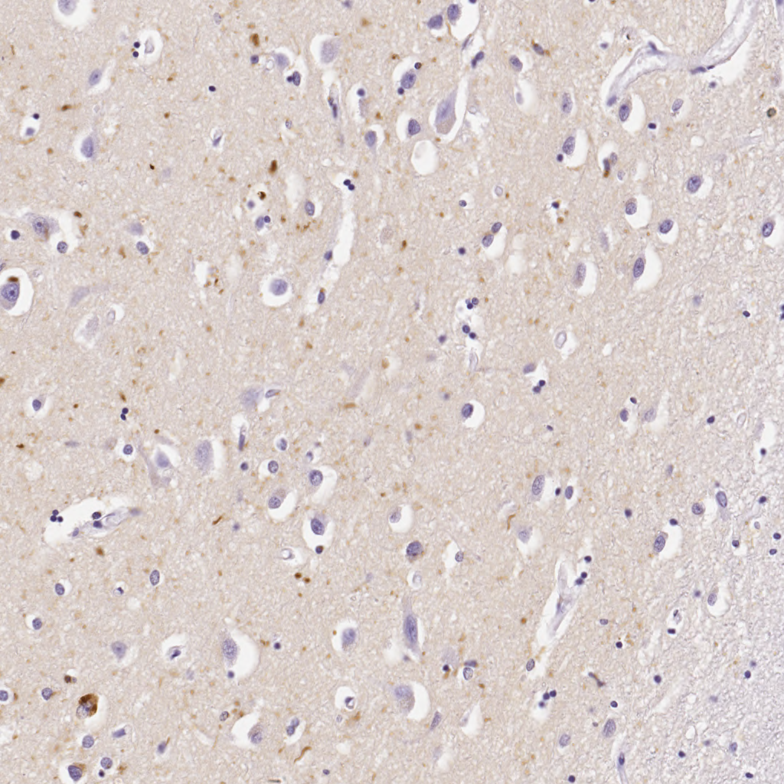

In [50]:
Image.fromarray(img)

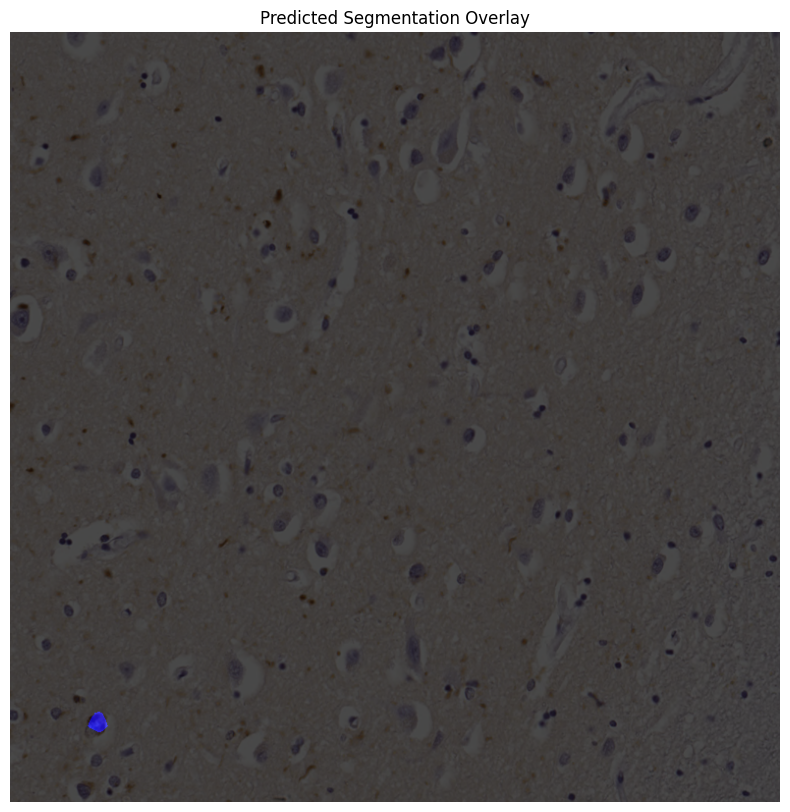

In [53]:

visualize_prediction(test_imgs_all[17], pred_mask, alpha=0.3)

In [19]:
import torch
import numpy as np

def compute_metrics(pred_mask, true_mask, num_classes=2):
    """
    pred_mask: torch.Tensor or np.array (H, W) — predicted class per pixel
    true_mask: torch.Tensor or np.array (H, W) — ground truth class per pixel
    """
    if isinstance(pred_mask, torch.Tensor):
        pred_mask = pred_mask.cpu().numpy()
    if isinstance(true_mask, torch.Tensor):
        true_mask = true_mask.cpu().numpy()

    ious = []
    dices = []
    pixel_acc = np.mean(pred_mask == true_mask)

    for cls in range(1,num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()
        iou = intersection / union if union > 0 else np.nan

        dice = (2 * intersection) / (pred_cls.sum() + true_cls.sum()) if (pred_cls.sum() + true_cls.sum()) > 0 else np.nan

        ious.append(iou)
        dices.append(dice)

    mean_iou = np.nanmean(ious)
    mean_dice = np.nanmean(dices)

    return {
        "pixel_accuracy": pixel_acc,
        "iou_per_class": ious,
        "mean_iou": mean_iou,
        "dice_per_class": dices,
        "mean_dice": mean_dice
    }


In [20]:
for img_path, mask_path in zip(test_imgs,test_masks):
    img, pred_mask = make_prediction(img_path)
    mask = Image.open(mask_path).convert("P").resize((784, 784))
    true_mask = np.array(mask)//50
    print(np.unique(true_mask))
    print(np.unique(pred_mask))
    metrics = compute_metrics(pred_mask, true_mask, num_classes=4)
    print(metrics)

[0 2]
[0 2]
{'pixel_accuracy': 0.9997901265097876, 'iou_per_class': [nan, 0.07857142857142857, nan], 'mean_iou': 0.07857142857142857, 'dice_per_class': [nan, 0.1456953642384106, nan], 'mean_dice': 0.1456953642384106}
[0 2]
[0 2]
{'pixel_accuracy': 0.9997413187213661, 'iou_per_class': [nan, 0.04216867469879518, nan], 'mean_iou': 0.04216867469879518, 'dice_per_class': [nan, 0.08092485549132948, nan], 'mean_dice': 0.08092485549132948}
[0 2]
[0 3]
{'pixel_accuracy': 0.9993785141607664, 'iou_per_class': [nan, 0.0, 0.0], 'mean_iou': 0.0, 'dice_per_class': [nan, 0.0, 0.0], 'mean_dice': 0.0}
[0 2]
[0 2]
{'pixel_accuracy': 0.999879607455227, 'iou_per_class': [nan, 0.08641975308641975, nan], 'mean_iou': 0.08641975308641975, 'dice_per_class': [nan, 0.1590909090909091, nan], 'mean_dice': 0.1590909090909091}
[0 1]
[0 1]
{'pixel_accuracy': 0.9998649651187005, 'iou_per_class': [0.7014388489208633, nan, nan], 'mean_iou': 0.7014388489208633, 'dice_per_class': [0.8245243128964059, nan, nan], 'mean_dice'

In [21]:
metrics

{'pixel_accuracy': 0.999879607455227,
 'iou_per_class': [0.5722543352601156, nan, nan],
 'mean_iou': 0.5722543352601156,
 'dice_per_class': [0.7279411764705882, nan, nan],
 'mean_dice': 0.7279411764705882}

In [20]:
image = Image.open(test_img).convert("RGB") #s[1]
transform = transforms.Compose([
    transforms.Resize((784, 784)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
input_tensor = transform(image).unsqueeze(0).to(device)  # (1, 3, 1022, 1022)
model.eval()
with torch.no_grad():
    # Get the backbone only
    backbone = model.backbone
    output = backbone.get_intermediate_layers(input_tensor, n=1)[0]  # (1, N+1, C)

In [21]:
cls_token = output[:, 0]             # (1, C)
patch_tokens = output[:, 1:]         # (1, N, C)


In [22]:
cls_token.shape

torch.Size([1, 1536])

In [23]:
patch_tokens.shape

torch.Size([1, 3135, 1536])

In [ ]:
3136 -> (1, 1536), 3135 

In [24]:
56*56

3136

In [25]:
feat_dim = patch_tokens.shape[-1]

In [26]:
feat_dim

1536

In [27]:
output.shape[1]

3136

In [28]:
spatial_dim = int(output.shape[1]** 0.5)

In [29]:
spatial_dim

56

In [30]:
output.permute(0, 2, 1).shape

torch.Size([1, 1536, 3136])

In [31]:
patch_features = output.permute(0, 2, 1).reshape(1, feat_dim, spatial_dim, spatial_dim)

In [32]:
patch_features.shape

torch.Size([1, 1536, 56, 56])

In [33]:
activation_map = patch_features.squeeze(0).mean(0, keepdim=True).unsqueeze(0) 

In [34]:
activation_map.shape

torch.Size([1, 1, 56, 56])

In [35]:

activation_map = F.interpolate(activation_map, size=(784, 784), mode="bilinear", align_corners=False)


In [36]:
activation_map.shape

torch.Size([1, 1, 784, 784])

In [38]:
import cv2
activation_map = patch_features.squeeze(0).mean(0, keepdim=True).unsqueeze(0) 
activation_map = F.interpolate(activation_map, size=(784, 784), mode="bilinear", align_corners=False)
activation_map = activation_map.squeeze().cpu().numpy()
activation_map_blurred = cv2.GaussianBlur(activation_map, (5, 5), sigmaX=1.5)

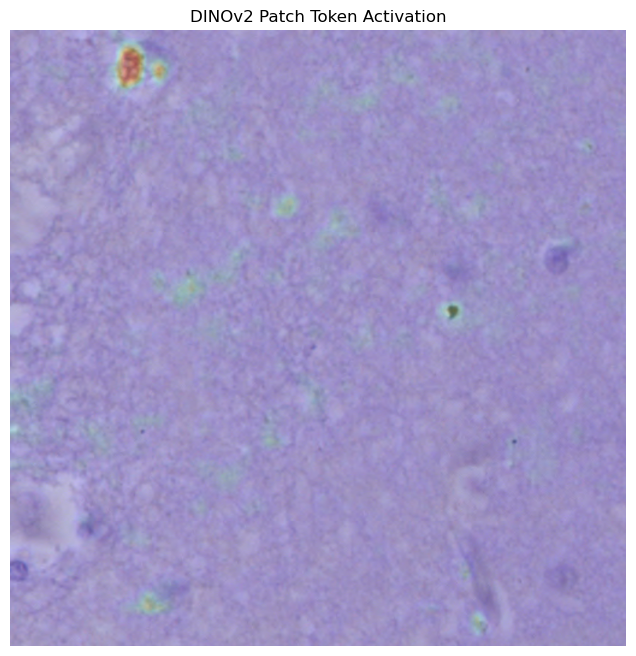

In [40]:
img = Image.open(test_img).convert("RGB").resize((784, 784))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.imshow(activation_map_blurred, cmap="jet", alpha=0.2)
plt.axis("off")
plt.title("DINOv2 Patch Token Activation")
plt.show()


In [122]:
1008/14

72.0

In [126]:
import datetime
datetime.datetime.now().strftime('%Y%m%d%H%M%S')

'20250502161531'

In [125]:
str(time.time())

'1746227713.8484282'

In [14]:
import numpy as np
from skimage.measure import regionprops, label


In [16]:
pred_mask.shape

(784, 784)

In [17]:
labeled_mask = label(pred_mask)

In [34]:
labeled_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [19]:
props = regionprops(labeled_mask)

In [20]:
props

In [21]:
features = []

In [24]:
for region in props:
    feats = {
        'area': region.area,
        'perimeter': region.perimeter,
        'eccentricity': region.eccentricity,
        'major_axis_length': region.major_axis_length,
        'minor_axis_length': region.minor_axis_length,
        'solidity': region.solidity,
        'extent': region.extent,
        'aspect_ratio': region.major_axis_length / region.minor_axis_length if region.minor_axis_length != 0 else 0,
        'circularity': (4 * np.pi * region.area) / (region.perimeter ** 2) if region.perimeter > 0 else 0,
        'bbox': region.bbox,
        'centroid': region.centroid,
        'label':region.label
    }
    features.append(feats)

In [25]:
features

[{'area': 92,
  'perimeter': 37.45584412271571,
  'eccentricity': 0.4646569168303149,
  'major_axis_length': 11.968607332823906,
  'minor_axis_length': 10.598091633079346,
  'solidity': 0.8846153846153846,
  'extent': 0.5443786982248521,
  'aspect_ratio': 1.129317215513294,
  'circularity': 0.8240593918021004,
  'bbox': (29, 152, 42, 165),
  'centroid': (34.78260869565217, 158.68478260869566)},
 {'area': 18,
  'perimeter': 13.313708498984761,
  'eccentricity': 0.3973597071195132,
  'major_axis_length': 5.033222956847166,
  'minor_axis_length': 4.618802153517006,
  'solidity': 1.0,
  'extent': 0.6,
  'aspect_ratio': 1.0897247358851685,
  'circularity': 1.2760987441597629,
  'bbox': (354, 564, 360, 569),
  'centroid': (356.5, 566.0)},
 {'area': 92,
  'perimeter': 37.45584412271571,
  'eccentricity': 0.4646569168303149,
  'major_axis_length': 11.968607332823906,
  'minor_axis_length': 10.598091633079346,
  'solidity': 0.8846153846153846,
  'extent': 0.5443786982248521,
  'aspect_ratio': 1

In [26]:
import torch

In [27]:
state_dict_weights = torch.load("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/feature_extractor/runs/May19_10-26-26_kif-gh200-01.gladstone.internal/checkpoints/model.pth")

/tmp/ipykernel_979078/3019066211.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_weights = torch.load("/gladstone/finkbeiner/steve/work/data/npsad_data/monika

In [29]:
state_dict_weights.keys()

odict_keys(['features.0.weight', 'features.4.0.conv1.weight', 'features.4.0.conv2.weight', 'features.4.1.conv1.weight', 'features.4.1.conv2.weight', 'features.5.0.conv1.weight', 'features.5.0.conv2.weight', 'features.5.0.downsample.0.weight', 'features.5.1.conv1.weight', 'features.5.1.conv2.weight', 'features.6.0.conv1.weight', 'features.6.0.conv2.weight', 'features.6.0.downsample.0.weight', 'features.6.1.conv1.weight', 'features.6.1.conv2.weight', 'features.7.0.conv1.weight', 'features.7.0.conv2.weight', 'features.7.0.downsample.0.weight', 'features.7.1.conv1.weight', 'features.7.1.conv2.weight', 'l1.weight', 'l1.bias', 'l2.weight', 'l2.bias'])

In [30]:
state_dict_weights = torch.load("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/Antibodies_detection/codes/tmi2022/feature_extractor/model.pth")

/tmp/ipykernel_979078/747451243.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict_weights = torch.load("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/

In [31]:
state_dict_weights.keys()

odict_keys(['feature_extractor.conv1.weight', 'feature_extractor.layer1.0.conv1.weight', 'feature_extractor.layer1.0.conv2.weight', 'feature_extractor.layer1.1.conv1.weight', 'feature_extractor.layer1.1.conv2.weight', 'feature_extractor.layer2.0.conv1.weight', 'feature_extractor.layer2.0.conv2.weight', 'feature_extractor.layer2.0.downsample.0.weight', 'feature_extractor.layer2.1.conv1.weight', 'feature_extractor.layer2.1.conv2.weight', 'feature_extractor.layer3.0.conv1.weight', 'feature_extractor.layer3.0.conv2.weight', 'feature_extractor.layer3.0.downsample.0.weight', 'feature_extractor.layer3.1.conv1.weight', 'feature_extractor.layer3.1.conv2.weight', 'feature_extractor.layer4.0.conv1.weight', 'feature_extractor.layer4.0.conv2.weight', 'feature_extractor.layer4.0.downsample.0.weight', 'feature_extractor.layer4.1.conv1.weight', 'feature_extractor.layer4.1.conv2.weight', 'fc.weight', 'fc.bias'])